In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pytensor.tensor as pt
import pymc as pm
from scipy.stats import norm
from pathlib import Path
from utils import extract_psychometric, cumulative_normal
import pytensor

pytensor.config.mode = "NUMBA"
plt.rcParams["figure.constrained_layout.use"] = True

- add Bayes Factors on interoceptive sensitivity

In [2]:
hrd_path = Path.cwd().parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
hrd_df = hrd_df[hrd_df.task == "hrd-session2"]

In [83]:
participant_id = "sub-0132"
df = hrd_df[hrd_df.participant_id == participant_id]
df.head()

,participant_id,id,task,cohort,StaircaseType,Condition,Modality,Decision,DecisionRT,Confidence,...,nTrials,EstimatedThreshold,EstimatedSlope,StartListening,StartDecision,ResponseMade,RatingStart,RatingEnds,endTrigger,session
27161,sub-0132,132,hrd-session2,vmp1,psi,Less,Extero,More,2.749498,19.0,...,0,-23.245423,12.550553,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,2
27162,sub-0132,132,hrd-session2,vmp1,psi,Less,Intero,More,1.481459,36.0,...,1,-23.245423,12.550553,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,2
27163,sub-0132,132,hrd-session2,vmp1,psi,Less,Intero,Less,1.882253,80.0,...,2,-10.897010,12.875481,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,2
27164,sub-0132,132,hrd-session2,vmp1,psiCatchTrial,Less,Extero,Less,1.531966,100.0,...,3,NaN,NaN,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,2
27165,sub-0132,132,hrd-session2,vmp1,psi,Less,Extero,Less,1.882869,100.0,...,4,-10.897010,12.875481,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,1.603365e+09,2


In [84]:
heart_rate = df[df.Modality == "Intero"].listenBPM.to_numpy()
intero_tone_2 = df[df.Modality == "Intero"].responseBPM.to_numpy()
extero_tone_1 = df[df.Modality == "Extero"].listenBPM.to_numpy()
extero_tone_2 = df[df.Modality == "Extero"].responseBPM.to_numpy()

extero_decision = (df[df.Modality == "Extero"].Decision.to_numpy() == "More").astype(
    int
)
intero_decision = (df[df.Modality == "Intero"].Decision.to_numpy() == "More").astype(
    int
)

## Standard Bayesian Psychophysics

In [85]:
with pm.Model() as standard_model:
    # exteroception ------------------------------
    extero_threshold = pm.Uniform("extero_threshold", lower=-50, upper=50)
    extero_slope = pm.Uniform("extero_slope", lower=0.1, upper=20)
    theta_extero = pm.Deterministic(
        "theta_extero",
        cumulative_normal(
            extero_tone_2 - extero_tone_1, extero_threshold, extero_slope
        ),
    )
    bin_extero = pm.Binomial(
        "bin_extero", p=theta_extero, n=1, observed=extero_decision
    )

    # interoception ------------------------------
    intero_threshold = pm.Uniform("intero_threshold", lower=-50, upper=50)
    intero_slope = pm.Uniform("intero_slope", lower=0.1, upper=20)
    theta_intero = pm.Deterministic(
        "theta_intero",
        cumulative_normal(intero_tone_2 - heart_rate, intero_threshold, intero_slope),
    )
    bin_intero = pm.Binomial(
        "bin_intero", p=theta_intero, n=1, observed=intero_decision
    )

    idata_standard_model = pm.sample(
        chains=4,
        cores=4,
        tune=1000,
        draws=1000,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [extero_threshold, extero_slope, intero_threshold, intero_slope]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


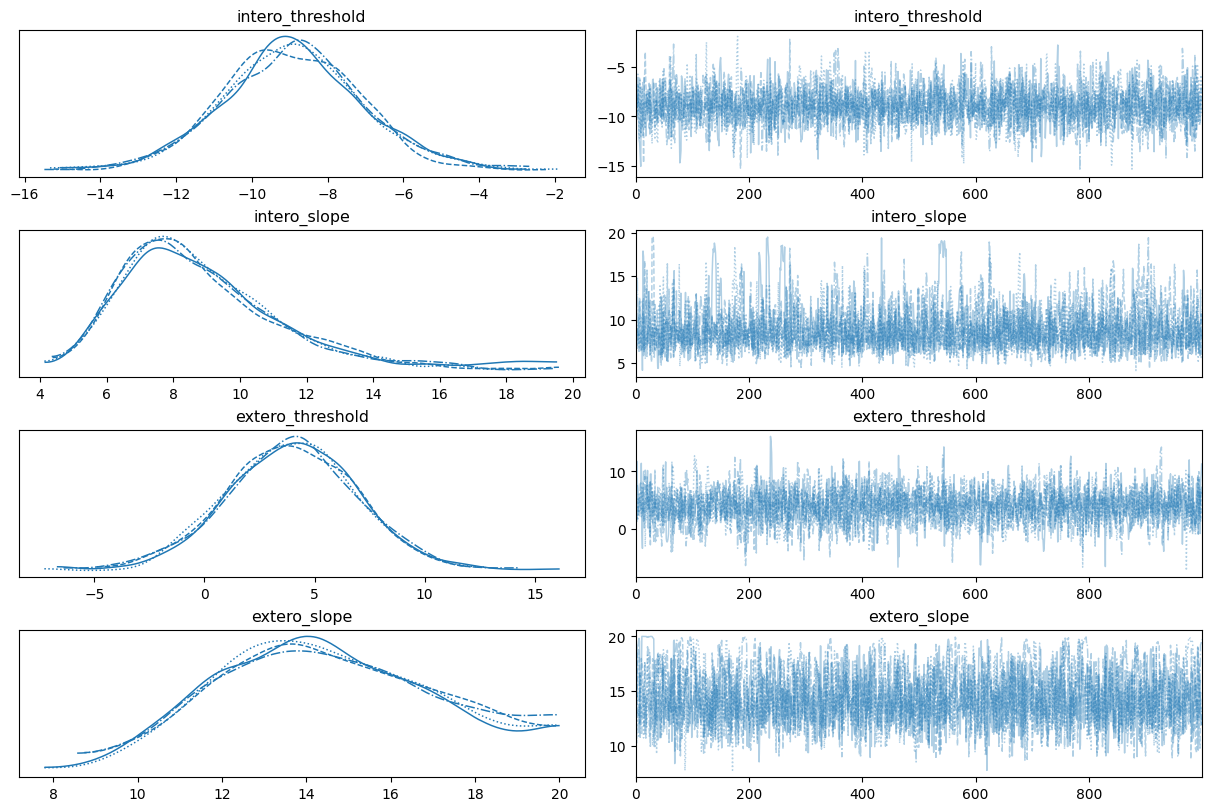

In [86]:
az.plot_trace(
    idata_standard_model,
    var_names=["intero_threshold", "intero_slope", "extero_threshold", "extero_slope"],
);

In [87]:
az.summary(
    idata_standard_model,
    var_names=["intero_threshold", "intero_slope", "extero_threshold", "extero_slope"],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intero_threshold,-8.927,1.857,-12.403,-5.391,0.033,0.035,3085.0,2342.0,1.00
intero_slope,8.895,2.519,4.903,13.661,0.071,0.094,1847.0,970.0,1.00
extero_threshold,3.960,2.973,-1.598,9.500,0.062,0.054,2296.0,2078.0,1.01
extero_slope,14.503,2.550,10.523,19.819,0.067,0.048,1315.0,608.0,1.00


## Audiroty noise

In [88]:
with pm.Model() as shared_perceptive_noise:
    # exteroception ------------------------------
    extero_threshold = pm.Uniform("extero_threshold", lower=-50, upper=50)
    extero_slope = pm.Uniform("extero_slope", lower=0.1, upper=20)
    theta_extero = pm.Deterministic(
        "theta_extero",
        cumulative_normal(
            extero_tone_2 - extero_tone_1,
            extero_threshold,
            pt.sqrt(2 * extero_slope**2),
        ),
    )
    bin_extero = pm.Binomial(
        "bin_extero", p=theta_extero, n=1, observed=extero_decision
    )

    # interoception ------------------------------
    intero_threshold = pm.Uniform("intero_threshold", lower=-50, upper=50)
    intero_slope = pm.Uniform("intero_slope", lower=0.1, upper=20)
    theta_intero = pm.Deterministic(
        "theta_intero",
        cumulative_normal(
            intero_tone_2 - heart_rate,
            intero_threshold,
            pt.sqrt(extero_slope**2 + intero_slope**2),
        ),
    )
    bin_intero = pm.Binomial(
        "bin_intero", p=theta_intero, n=1, observed=intero_decision
    )

    idata_shared_perceptive_noise = pm.sample(
        chains=4,
        cores=4,
        tune=1000,
        draws=1000,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [extero_threshold, extero_slope, intero_threshold, intero_slope]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


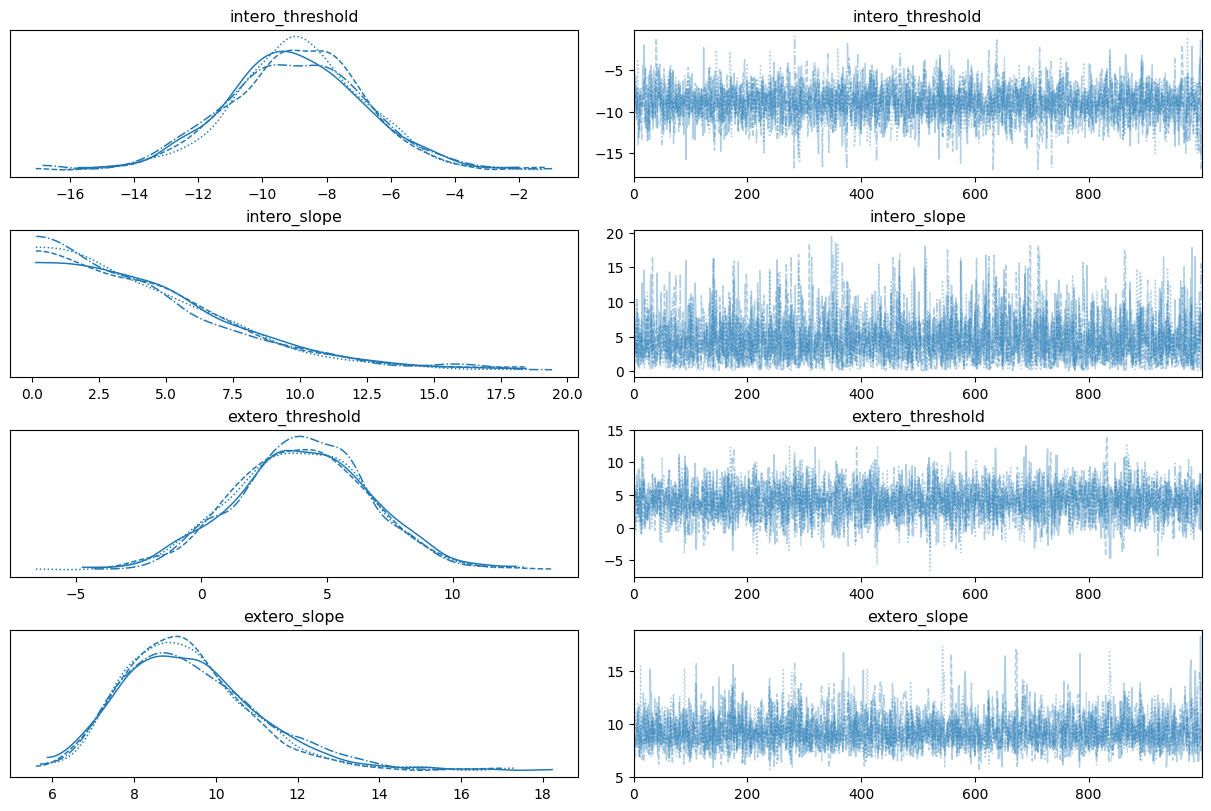

In [89]:
az.plot_trace(
    idata_shared_perceptive_noise,
    var_names=["intero_threshold", "intero_slope", "extero_threshold", "extero_slope"],
);

In [90]:
az.summary(
    idata_shared_perceptive_noise,
    var_names=["intero_threshold", "intero_slope", "extero_threshold", "extero_slope"],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intero_threshold,-8.941,2.160,-13.083,-4.978,0.036,0.037,3603.0,2765.0,1.0
intero_slope,4.481,3.444,0.108,10.783,0.058,0.065,3085.0,1922.0,1.0
extero_threshold,3.982,2.705,-1.140,8.904,0.044,0.046,3838.0,2702.0,1.0
extero_slope,9.330,1.644,6.592,12.467,0.030,0.036,3396.0,2144.0,1.0


## Weighted Bayesian update

In [91]:
with pm.Model() as weigthed_update:
    # exteroception ------------------------------
    extero_threshold = pm.Uniform("extero_threshold", lower=-50, upper=50)
    extero_slope = pm.Uniform("extero_slope", lower=0.1, upper=30)
    theta_extero = pm.Deterministic(
        "theta_extero",
        cumulative_normal(
            extero_tone_2 - extero_tone_1,
            extero_threshold,
            pt.sqrt(2 * extero_slope**2),
        ),
    )
    bin_extero = pm.Binomial(
        "bin_extero", p=theta_extero, n=1, observed=extero_decision
    )

    # interoception ------------------------------

    # priors over cardiac beliefs
    mu_cardiac_prior = pm.Uniform("mu_cardiac_prior", lower=20, upper=150)
    sigma_cardiac_prior = pm.Uniform("sigma_cardiac_prior", lower=0.1, upper=30)

    interoceptive_precision = 1.0
    interoceptive_sensitivity = pm.Beta("interoceptive_sensitivity", 1, 1)

    # update cardiac beliefs using physiological inputs
    sigma_cardiac_belief = pm.Deterministic(
        "sigma_cardiac_belief",
        pt.sqrt(
            1
            / (
                (1 / sigma_cardiac_prior**2)
                + (interoceptive_sensitivity / interoceptive_precision**2)
            )
        ),
    )
    mu_cardiac_belief = pm.Deterministic(
        "mu_cardiac_belief",
        sigma_cardiac_belief**2
        * (
            mu_cardiac_prior / (sigma_cardiac_prior**2)
            + (interoceptive_sensitivity * heart_rate / interoceptive_precision)
        ),
    )

    theta_intero = pm.Deterministic(
        "theta_intero",
        1.0
        - cumulative_normal(
            0.0,
            intero_tone_2 - mu_cardiac_belief,
            pt.sqrt(sigma_cardiac_belief**2 + extero_slope**2),
        ),
    )
    bin_intero = pm.Binomial(
        "bin_intero", p=theta_intero, n=1, observed=intero_decision
    )

    idata_weigthed_update = pm.sample(
        chains=4,
        cores=4,
        tune=1000,
        draws=1000,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [extero_threshold, extero_slope, mu_cardiac_prior, sigma_cardiac_prior, interoceptive_sensitivity]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


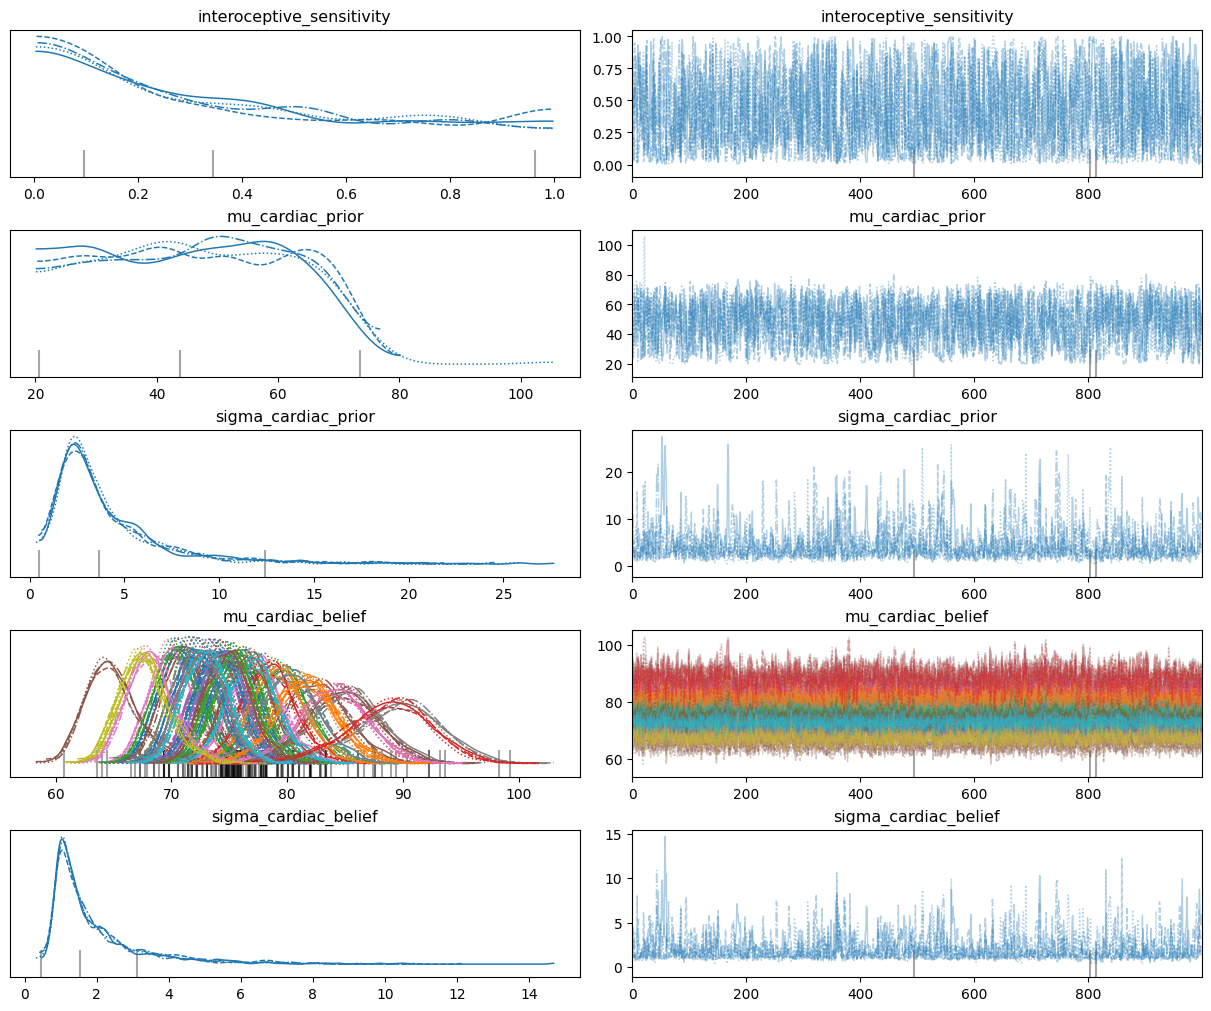

In [92]:
az.plot_trace(
    idata_weigthed_update,
    var_names=[
        "interoceptive_sensitivity",
        "mu_cardiac_prior",
        "sigma_cardiac_prior",
        "mu_cardiac_belief",
        "sigma_cardiac_belief",
    ],
);

In [93]:
az.summary(
    idata_weigthed_update,
    var_names=[
        "interoceptive_sensitivity",
        "mu_cardiac_prior",
        "sigma_cardiac_prior",
        "mu_cardiac_belief",
        "sigma_cardiac_belief",
    ],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
interoceptive_sensitivity,0.401,0.295,0.004,0.915,0.007,0.004,1613.0,1713.0,1.0
mu_cardiac_prior,46.723,15.130,20.459,69.887,0.397,0.186,1309.0,1044.0,1.0
sigma_cardiac_prior,4.187,3.379,0.407,10.032,0.094,0.153,1412.0,1744.0,1.0
mu_cardiac_belief[0],74.459,2.015,70.614,78.118,0.037,0.042,3153.0,2166.0,1.0
mu_cardiac_belief[1],76.982,2.203,72.806,81.138,0.041,0.047,3022.0,2062.0,1.0
...,...,...,...,...,...,...,...,...,...
mu_cardiac_belief[56],68.330,2.170,64.427,72.440,0.047,0.042,2321.0,1802.0,1.0
mu_cardiac_belief[57],72.656,1.968,69.030,76.384,0.037,0.038,2997.0,2232.0,1.0
mu_cardiac_belief[58],67.609,2.242,63.588,71.833,0.049,0.045,2245.0,1775.0,1.0
mu_cardiac_belief[59],73.017,1.971,69.478,76.797,0.037,0.038,3041.0,2199.0,1.0


In [94]:
with weigthed_update:
    prior = pm.sample_prior_predictive(samples=1000)

Sampling: [bin_extero, bin_intero, extero_slope, extero_threshold, interoceptive_sensitivity, mu_cardiac_prior, sigma_cardiac_prior]


## Visualisation

In [95]:
mu_cardiac_belief = az.summary(
    idata_weigthed_update,
    var_names=[
        "mu_cardiac_belief",
    ],
)["mean"].to_numpy()
sigma_cardiac_belief = az.summary(
    idata_weigthed_update,
    var_names=[
        "sigma_cardiac_belief",
    ],
)["mean"]["sigma_cardiac_belief"]

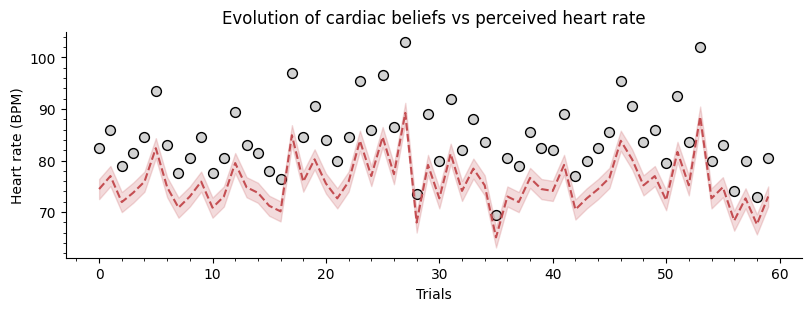

In [96]:
_, ax = plt.subplots(figsize=(8, 3))

ax.scatter(
    np.arange(0, len(heart_rate)), heart_rate, s=50, color="lightgrey", edgecolors="k"
)
ax.plot(np.arange(0, len(heart_rate)), mu_cardiac_belief, "--", color="#c44e52")
ax.fill_between(
    x=np.arange(0, len(heart_rate)),
    y1=mu_cardiac_belief - sigma_cardiac_belief,
    y2=mu_cardiac_belief + sigma_cardiac_belief,
    alpha=0.2,
    color="#c44e52",
)
ax.minorticks_on()
ax.set(
    title="Evolution of cardiac beliefs vs perceived heart rate",
    xlabel="Trials",
    ylabel="Heart rate (BPM)",
)
sns.despine()

## Model comparison

In [97]:
model_compare = az.compare(
    {
        "standard": idata_standard_model,
        "shared_noise": idata_shared_perceptive_noise,
        "weigthed_update": idata_weigthed_update,
    },
    var_name="bin_intero",
)

/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

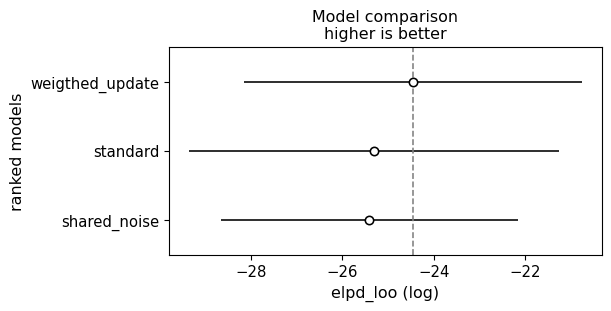

In [98]:
az.plot_compare(model_compare)